Saving talabat_enhanced_orders.csv to talabat_enhanced_orders (1).csv


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


(100000, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle   

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,499.832850,250.791800,2.991110,268.925734,37.520110,30.119015,31.063065,30.119060,31.062971,30.119075,31.062993,2.165303
std,28867.657797,288.255257,144.289418,1.410132,170.490396,10.060876,1.271638,0.487754,1.271674,0.487811,1.271699,0.487826,1.038473
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.000000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25000.750000,250.000000,126.000000,2.000000,129.430000,30.000000,30.023110,31.008774,30.023370,31.008460,30.023295,31.008410,1.355602
50%,50000.500000,499.000000,251.000000,3.000000,233.200000,38.000000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75000.250000,750.000000,376.000000,4.000000,381.510000,45.000000,31.026912,31.371676,31.027112,31.371856,31.027241,31.371508,2.924525
max,100000.000000,1000.000000,500.000000,5.000000,750.000000,60.000000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


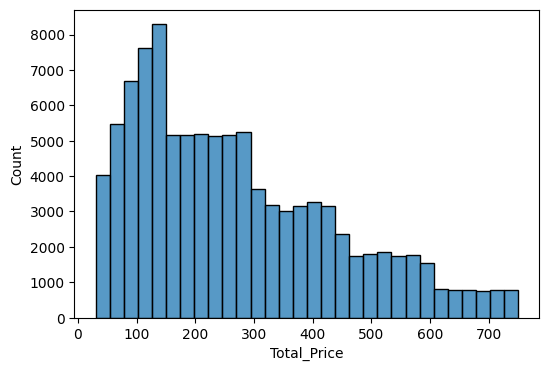

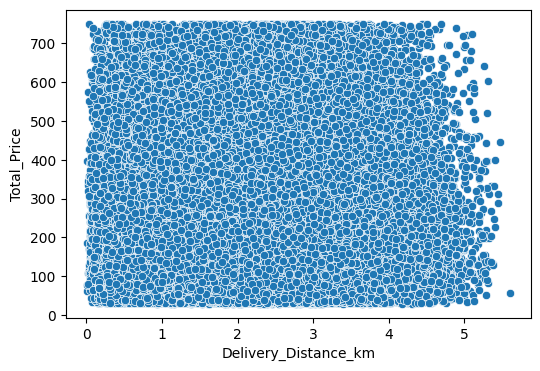

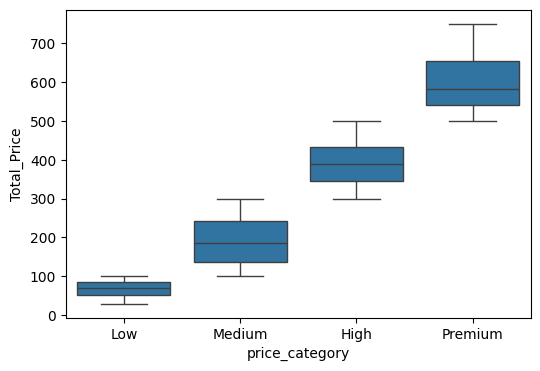

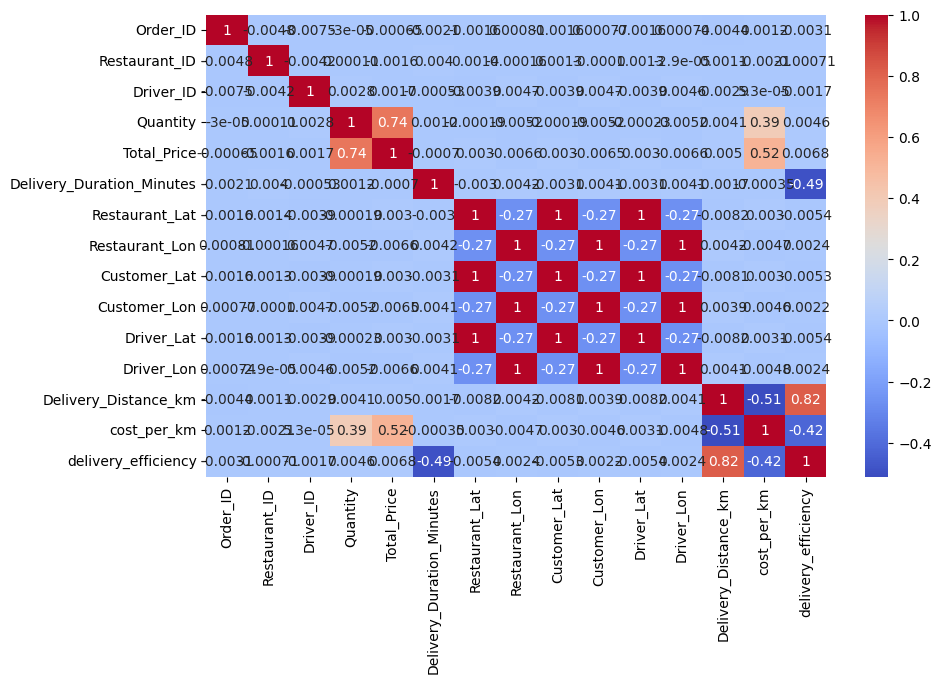

/tmp/ipykernel_1364/640023581.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_category")[["Total_Price","Delivery_Distance_km","Delivery_Duration_Minutes"]]


,Total_Price,Delivery_Distance_km,Delivery_Duration_Minutes
price_category,,,
Low,69.174690,2.154502,37.474574
Medium,191.453454,2.162832,37.562459
High,390.733017,2.179478,37.477135
Premium,598.679158,2.161998,37.490666


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
files.upload()

df = pd.read_csv("talabat_enhanced_orders.csv")

display(df.head())

print(df.shape)

df.info()

print(df.isnull().sum())

display(df.describe())

df["cost_per_km"] = df["Total_Price"] / (df["Delivery_Distance_km"] + 0.1)

df["delivery_efficiency"] = df["Delivery_Distance_km"] / (df["Delivery_Duration_Minutes"] + 1)

df["price_category"] = pd.cut(
    df["Total_Price"],
    bins=[0,100,300,500,1000],
    labels=["Low","Medium","High","Premium"]
)

plt.figure(figsize=(6,4))
sns.histplot(df["Total_Price"], bins=30)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Delivery_Distance_km"], y=df["Total_Price"])
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["price_category"], y=df["Total_Price"])
plt.show()

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

display(
    df.groupby("price_category")[["Total_Price","Delivery_Distance_km","Delivery_Duration_Minutes"]]
    .mean()
)
